# Secondary-Offering-Drift — does a stock keep sliding after it sells fresh shares? 💧
### When a company prints new stock to raise cash, in plain English

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Dilution_drift%3F: Busted](https://img.shields.io/badge/Dilution_drift%3F-Busted-8b949e?style=flat-square)

Here's a piece of market folklore that *sounds* airtight. When a public company needs cash, it can **sell a fresh slug of new shares** to the market — a *secondary* or *follow-on* offering. Two things are supposed to happen: (1) **dilution** — the pie is now cut into more slices, so each existing share is worth a little less; and (2) a **bad signal** — management chose to sell equity *now*, which whispers 'we think our stock is about as expensive as it's going to get.' Put together, the stock is supposed to **drift down for months** afterward.

So we test it the cheap way: take **34** notable, recognisable offerings, and see whether the stock really slid in the months after — *beyond* whatever the whole market was doing.

> 📓 **This is the plain-language layer.** Want the *t*-stats, the placebo test and the cost maths? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** A reproducible research tool: every chart is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from secondary_offering_drift import data, strategy as st

HAVE_REAL = data.have_real()
PRICES, EVENTS = data.load_real() if HAVE_REAL else (None, None)
if HAVE_REAL:
    PRICES = PRICES.loc[:"2026-06-30"]           # drop the partial current bar (as-of stamp)
print("real event-price cache present:", HAVE_REAL,
      "| offerings in table:", len(data.event_table()))


real event-price cache present: True | offerings in table: 34


## The answer first 🎯

| Question | Answer |
|---|---|
| Did the stock slide after the offering (the claim)? | **No — the opposite.** Over the next month the issuers *beat* the market by **+11%** on average; over the next *year*, by **+29%**. The 'diluted' stocks *ripped*. |
| Is that rip a real edge, then? | **No** — it never clears the significance bar (best *t* = +1.78), and it's driven by a handful of moonshots. Positive on average, but inside the noise. |
| So is the dilution story just wrong? | **On this basket, backwards.** The names we can recognise and name are growth-story high-fliers (Tesla, crypto miners, pandemic winners) that raised cash *at strength* — and kept climbing. |
| Could you trade it (short the issuer)? | **No.** Shorting these names *loses* money before costs, and they're exactly the expensive-to-borrow stocks. |

> The dilution effect is real in the textbooks (and there *is* a small negative pop on the *day* of the announcement). But the months-long *slide* the folklore promises isn't here — our sample is survivors and headliners that grew into their new shares.

## 1 · The claim

> *"After a company sells a fresh slug of shares in a secondary offering, the stock keeps sliding."* — the dilution + negative-signalling story (Loughran-Ritter 1995; Myers-Majluf 1984).

Why it *should* be true: more shares outstanding means each one owns a smaller piece of the same company (dilution), and a manager who sells equity is implicitly saying the stock is fully priced (a bearish signal). Both point the same way — down. The academic 'new issues puzzle' even documents issuers *under*performing for years afterward.

## 2 · So what?

If true, it's a clean short: when a company you follow prints stock, fade it. It's the mirror image of the **buyback** story ([Study 368](../../368-buyback-drift/) — buy back shares, drift up) and the discrete-event cousin of the **net-share-issuance** factor ([Study 519](../../519-net-share-issuance/) — diluters underperform). We go straight at the *event*: mark each offering, and look at what the stock did next — beyond the market.

## 3 · How would we even know?

1. **Mark the offerings.** 34 notable follow-on / secondary raises (ticker, pricing date, size).
2. **Strip the market.** For each, measure the stock's return *minus SPY's* over the next 1 / 3 / 6 / 12 months — the **abnormal** return. That way a bull (or bear) market can't masquerade as offering drift.
3. **Enter one day later.** We act the day *after* the offering is public — no peeking, and it steps past the small same-day pop so we measure the *drift*, not the jump.

Catch: our list is companies we can *recognise* — which skews to survivors and headline growth names. The messy distressed dilutions, where the bad signal bites hardest, are under-represented. We'll see that bias flip the whole result.

## 4 · The teardown — let's actually look

**Did the stock slide (claim) or climb (tape) after the offering, beyond the market?**

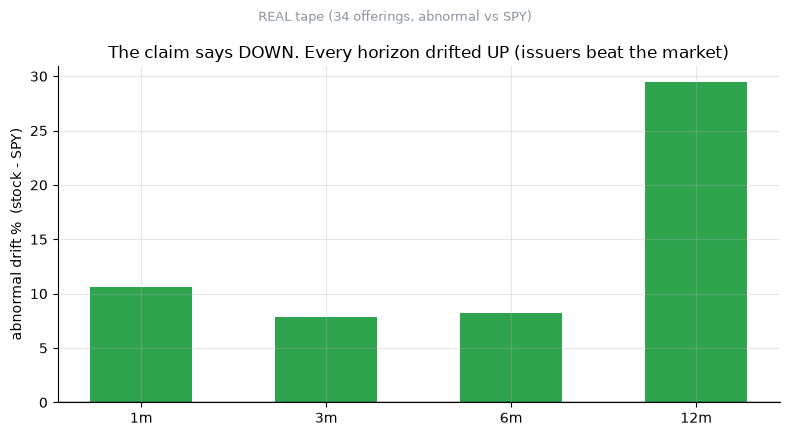

abnormal drift by horizon: [10.6, 7.8, 8.2, 29.4]


In [2]:
hor = [1, 3, 6, 12]
if HAVE_REAL:
    means = [st.summarize(PRICES, EVENTS, m)['ab_mean']*100 for m in hor]
    banner = 'REAL tape (34 offerings, abnormal vs SPY)'
else:
    means = [10.6, 7.83, 8.21, 29.44]
    banner = 'frozen real numbers (offline)'
fig, ax = plt.subplots(figsize=(8, 4.4))
cols = [GREEN if m>0 else RED for m in means]
ax.bar([f'{m}m' for m in hor], means, color=cols, width=.55)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('abnormal drift %  (stock - SPY)')
ax.set_title('The claim says DOWN. Every horizon drifted UP (issuers beat the market)')
fig.suptitle(banner, fontsize=9, color=GREY); plt.tight_layout(); plt.show()
print('abnormal drift by horizon:', [round(m,1) for m in means])

There it is, **backwards**. The dilution story predicts a slide. On these 34 offerings the issuers *beat* the market at every horizon — **+11%** at one month, **+29%** at a year. The 'diluted' names climbed. Why? The recognisable offerings are growth-story high-fliers raising cash while their stock was hot — and they stayed hot.

**Is that climb a real signal, or a few moonshots dragging the average up?** Compare the *average* drift to the *typical* (median) one, and count how often the stock actually fell (the 'loss-rate' — a real down-drift would push it above 50%).

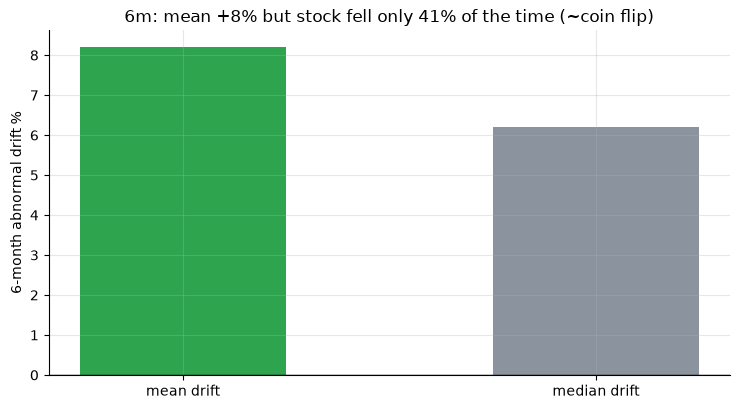

6m mean +8.2% | median +6.2% | fell 41% of the time


In [3]:
if HAVE_REAL:
    s6 = st.summarize(PRICES, EVENTS, 6)
    mean6, med6, loss6 = s6['ab_mean']*100, s6['ab_median']*100, s6['loss']*100
else:
    mean6, med6, loss6 = 8.21, 6.19, 41
fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.bar(['mean drift','median drift'], [mean6, med6], color=[GREEN, GREY], width=.5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('6-month abnormal drift %')
ax.set_title(f'6m: mean +{mean6:.0f}% but stock fell only {loss6:.0f}% of the time (~coin flip)')
plt.tight_layout(); plt.show()
print(f'6m mean +{mean6:.1f}% | median +{med6:.1f}% | fell {loss6:.0f}% of the time')

The stock fell only **41%** of the time at six months — a coin flip, if anything *below* it. The mean is dragged up by a few explosive winners; there is no reliable down-drift to short. Whatever the textbooks say, *this* basket did not slide.

## 5 · The verdict

- **Signal — None.** The drift is the *wrong sign* (up, not down) at every horizon and never clears the significance bar. No slide to bank.
- **Tradability — Mirage.** The trade would be to *short* the issuer — which *lost* money here, before you even pay the (steep) borrow on these hard-to-borrow names.
- **Dilution drift on the tape? — Busted.** On recognisable, survived growth-story raisers, the issuers out-ran the market for a year. The effect the folklore promises is absent-to-inverted on this sample.

## 6 · Could you actually trade it?

No. The tradable version of 'the stock slides' is to **short the issuer** — but on this basket that short *loses* money, because the stocks went up. And these are exactly the kind of hot, hard-to-borrow names (Tesla, crypto miners) where shorting is expensive and dangerous. Wrong sign, worst possible names to be short. There's no trade here.

## 7 · Going further 🚪

- **The factor version.** [Study 519 — Net-Share-Issuance](../../519-net-share-issuance/) tests the *continuous* version (rank firms by how much stock they printed) on a broad basket.
- **The mirror image.** [Study 368 — Buyback-Drift](../../368-buyback-drift/): does a stock drift *up* after a buyback? (Faintly, but not significantly either.)
- **The real test needs the ugly deals.** Re-run this with *distressed* dilutions (near-bankruptcy raises, deep-discount rights issues) and a survivorship-free universe — that's where the negative signal should bite.

*Think the slide is real and we just cherry-picked winners? Fork this, add 100 messy small-cap distressed offerings, and show the abnormal drift clearing t = −2 the way the dilution story predicts.*